# 05 - Comparaison des modèles de détection de régime

**Objectif** : Comparer K-Means, GMM et HMM pour la détection de régime de marché.

**Modèles testés** :
- K-Means (baseline clustering)
- GMM - Gaussian Mixture Model (probabiliste)
- HMM - Hidden Markov Model (temporel)

**Métriques** :
- Silhouette Score (qualité des clusters)
- Calinski-Harabasz Index
- Stabilité des régimes (durée moyenne)
- Adjusted Rand Index vs labels historiques

In [27]:
# Imports
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Modules ML DeepPilot
from ml.config import N_REGIMES, REGIME_NAMES, ETF_TICKERS
from ml.features.feature_engineering import prepare_regime_features
from ml.models.regime_kmeans import RegimeKMeans
from ml.models.regime_gmm import RegimeGMM
from ml.models.regime_hmm import RegimeHMM
from ml.evaluation.regime_labels import create_historical_labels, get_crisis_periods
from ml.evaluation.compare_regime_models import (
    evaluate_regime_model,
    compare_all_regime_models,
)

# Database
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os

load_dotenv()

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Imports OK")

Imports OK


## 1. Chargement des données

In [28]:
# Connexion à la base de données
DATABASE_URL = os.getenv("SUPABASE_DB_URL")
engine = create_engine(DATABASE_URL)

print("Connexion DB OK")

Connexion DB OK


In [29]:
# Charger les prix ETF
query_prices = """
SELECT date, ticker, close
FROM price
WHERE ticker IN ('SPY', 'TLT', 'GLD', 'VNQ', 'EFA', 'EEM', 'HYG', 'SH')
ORDER BY date, ticker
"""

df_prices_long = pd.read_sql(query_prices, engine, parse_dates=['date'])
df_prices = df_prices_long.pivot(index='date', columns='ticker', values='close')

print(f"Prix ETF : {df_prices.shape[0]} jours, {df_prices.shape[1]} tickers")
print(f"Période : {df_prices.index.min().date()} à {df_prices.index.max().date()}")

Prix ETF : 4109 jours, 8 tickers
Période : 2010-01-04 à 2026-05-05


In [30]:
# Charger les données macro
query_macro = """
SELECT date, vix, credit_spread_hy, yield_curve_10y2y, t10y as treasury_10y
FROM macro_indicator
ORDER BY date
"""

df_macro = pd.read_sql(query_macro, engine, parse_dates=['date'])
df_macro = df_macro.set_index('date')

# Remplir les valeurs manquantes de credit_spread_hy
if df_macro['credit_spread_hy'].isna().any():
    df_macro['credit_spread_hy'] = df_macro['credit_spread_hy'].ffill().bfill()
    df_macro['credit_spread_hy'] = df_macro['credit_spread_hy'].fillna(4.5)
    print("[INFO] credit_spread_hy: valeurs manquantes remplies")

print(f"Données macro : {df_macro.shape[0]} jours")
print(f"Colonnes : {list(df_macro.columns)}")

[INFO] credit_spread_hy: valeurs manquantes remplies
Données macro : 4326 jours
Colonnes : ['vix', 'credit_spread_hy', 'yield_curve_10y2y', 'treasury_10y']


In [31]:
# Combiner prix et macro
df_combined = pd.concat([df_prices, df_macro], axis=1)
df_combined = df_combined.dropna()

print(f"Données combinées : {df_combined.shape[0]} jours")
print(f"Période finale : {df_combined.index.min().date()} à {df_combined.index.max().date()}")

Données combinées : 4109 jours
Période finale : 2010-01-04 à 2026-05-05


## 2. Préparation des features de régime

In [32]:
# Préparer les features
X_regime = prepare_regime_features(df_combined)

print(f"Features de régime : {X_regime.shape}")
print(f"Colonnes : {list(X_regime.columns)}")
X_regime.head()

Features de régime : (4050, 5)
Colonnes : ['vix_zscore', 'credit_spread_zscore', 'yield_curve_10y2y', 'spy_return_20d', 'spy_volatility_20d']


,vix_zscore,credit_spread_zscore,yield_curve_10y2y,spy_return_20d,spy_volatility_20d
date,,,,,
2010-03-30,-1.014623,-1.199560,2.82,0.050655,0.072921
2010-03-31,-0.849986,-1.301514,2.82,0.046143,0.075709
2010-04-01,-0.877072,-1.642819,2.84,0.050116,0.077404
2010-04-05,-1.010170,-1.715120,2.83,0.043755,0.067366
2010-04-06,-1.247137,-1.305587,2.84,0.046033,0.066961


In [33]:
# Statistiques des features
X_regime.describe().round(3)

,vix_zscore,credit_spread_zscore,yield_curve_10y2y,spy_return_20d,spy_volatility_20d
count,4050.000,4050.000,4050.000,4050.000,4050.000
mean,-0.072,-0.164,0.952,0.011,0.147
std,1.242,1.421,0.923,0.042,0.092
min,-2.056,-3.728,-1.080,-0.310,0.032
25%,-0.897,-1.296,0.260,-0.008,0.092
50%,-0.364,-0.473,0.870,0.017,0.124
75%,0.405,0.925,1.630,0.035,0.173
max,11.828,7.026,2.910,0.231,0.932


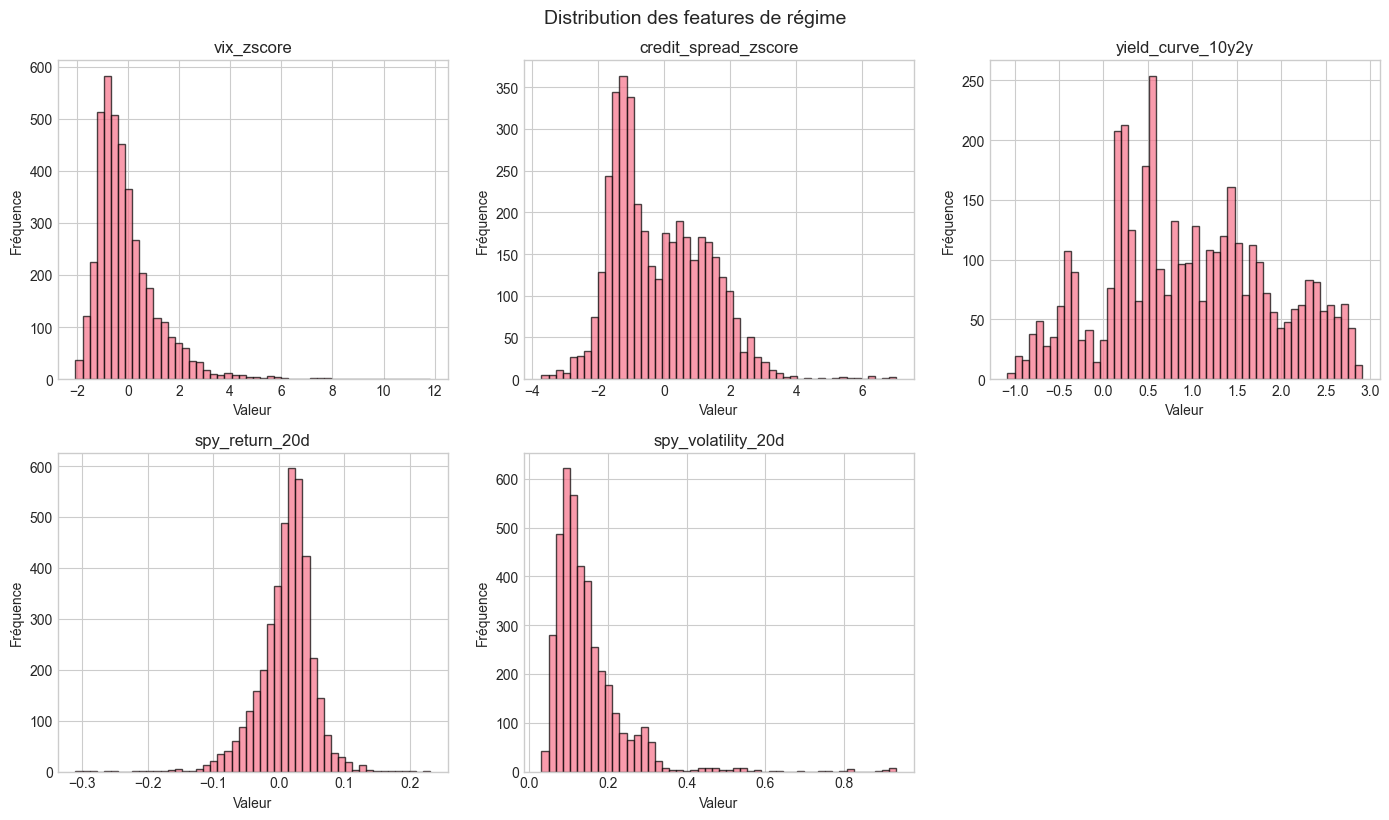

In [34]:
# Visualiser les distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(X_regime.columns):
    if i < len(axes):
        axes[i].hist(X_regime[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('Valeur')
        axes[i].set_ylabel('Fréquence')

# Masquer les axes non utilisés
for j in range(len(X_regime.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Distribution des features de régime', y=1.02, fontsize=14)
plt.show()

## 3. Création des labels historiques (ground truth)

In [35]:
# Créer les labels historiques basés sur des règles
y_historical = create_historical_labels(df_combined, spy_col='SPY', vix_col='vix')

# Aligner avec X_regime
common_idx = X_regime.index.intersection(y_historical.index)
y_historical = y_historical.loc[common_idx]

print(f"Labels historiques : {len(y_historical)} observations")
print(f"\nDistribution des régimes historiques :")
for regime, name in REGIME_NAMES.items():
    count = (y_historical == regime).sum()
    pct = count / len(y_historical) * 100
    print(f"  {name}: {count} ({pct:.1f}%)")

Labels historiques : 4050 observations

Distribution des régimes historiques :
  bull: 1376 (34.0%)
  bear: 56 (1.4%)
  volatile: 493 (12.2%)
  stable: 2125 (52.5%)


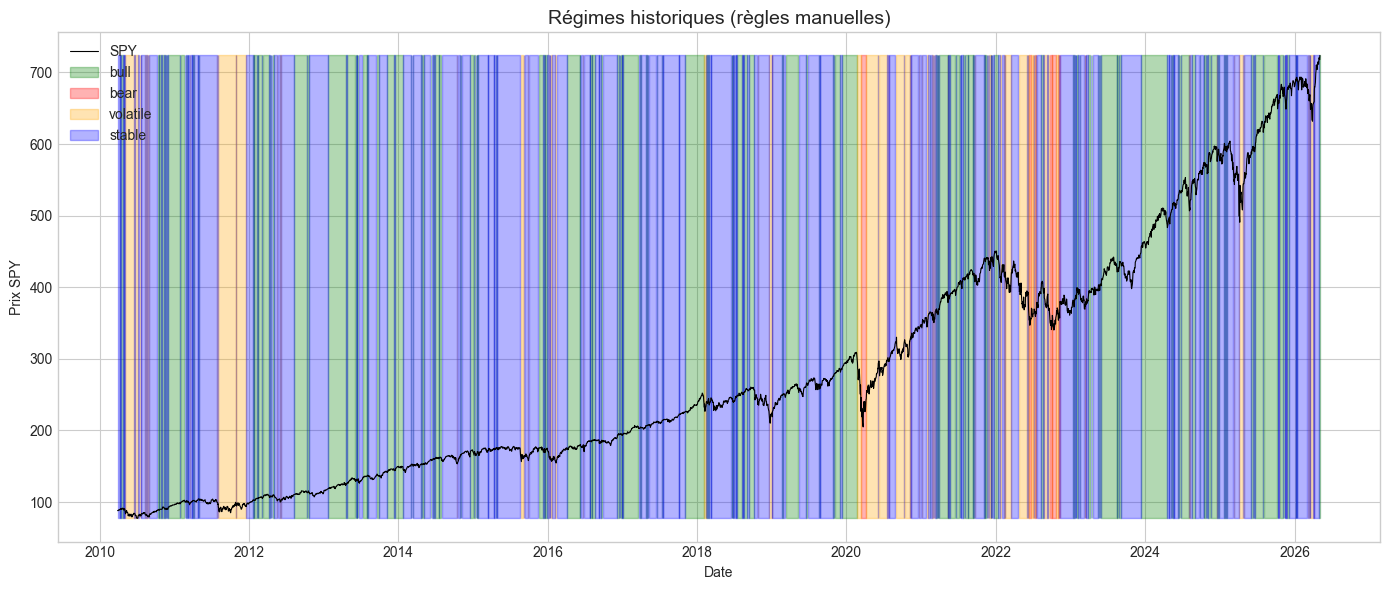

In [36]:
# Visualiser les régimes historiques
fig, ax = plt.subplots(figsize=(14, 6))

# Prix SPY
ax.plot(df_combined.loc[common_idx, 'SPY'], color='black', linewidth=0.8, label='SPY')

# Colorier selon le régime
colors = {0: 'green', 1: 'red', 2: 'orange', 3: 'blue'}
for regime, color in colors.items():
    mask = y_historical == regime
    if mask.any():
        ax.fill_between(
            y_historical.index, 
            df_combined.loc[common_idx, 'SPY'].min(),
            df_combined.loc[common_idx, 'SPY'].max(),
            where=mask,
            alpha=0.3,
            color=color,
            label=REGIME_NAMES[regime]
        )

ax.set_title('Régimes historiques (règles manuelles)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Prix SPY')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 4. Entraînement des modèles

In [37]:
# Données d'entraînement (alignées)
X_train = X_regime.loc[common_idx]

print(f"Données d'entraînement : {X_train.shape}")

Données d'entraînement : (4050, 5)


In [38]:
# Entraîner K-Means
print("Entraînement K-Means...")
model_kmeans = RegimeKMeans(n_regimes=N_REGIMES)
model_kmeans.fit(X_train)
labels_kmeans = model_kmeans.predict_series(X_train)
print("  OK")

# Entraîner GMM
print("Entraînement GMM...")
model_gmm = RegimeGMM(n_regimes=N_REGIMES)
model_gmm.fit(X_train)
labels_gmm = model_gmm.predict_series(X_train)
print("  OK")

# Entraîner HMM
print("Entraînement HMM...")
model_hmm = RegimeHMM(n_regimes=N_REGIMES)
model_hmm.fit(X_train)
labels_hmm = model_hmm.predict_series(X_train)
print("  OK")

print("\nTous les modèles entraînés !")

Entraînement K-Means...
  OK
Entraînement GMM...
  OK
Entraînement HMM...
  OK

Tous les modèles entraînés !


## 5. Comparaison des modèles

In [39]:
# Comparaison automatique
comparison_df = compare_all_regime_models(X_train, y_historical)

print("\n" + "="*60)
print("COMPARAISON DES MODÈLES DE RÉGIME")
print("="*60)
comparison_df

Entraînement K-Means...
Entraînement GMM...
Entraînement HMM...

COMPARAISON DES MODÈLES DE RÉGIME


,silhouette,calinski_harabasz,stability,regime_changes,adj_rand_index,accuracy_vs_hist
model,,,,,,
K-Means,0.2149,1308.54,0.9407,240,0.0970,0.3523
GMM,0.1468,808.93,0.9106,362,0.1113,0.3412
HMM,0.1991,1009.02,0.9790,85,0.0697,0.3679


In [40]:
# Évaluation détaillée de chaque modèle
models = {
    'K-Means': model_kmeans,
    'GMM': model_gmm,
    'HMM': model_hmm,
}

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"{name}")
    print('='*40)
    metrics = evaluate_regime_model(model, X_train, y_historical)
    
    print(f"Silhouette Score: {metrics['silhouette_score']}")
    print(f"Calinski-Harabasz: {metrics['calinski_harabasz']}")
    print(f"Stabilité: {metrics['stability']} ({metrics['regime_changes']} changements)")
    print(f"\nDistribution des régimes:")
    for regime, pct in metrics['distribution'].items():
        print(f"  {regime}: {pct*100:.1f}%")
    
    if 'vs_historical' in metrics:
        print(f"\nVs Labels historiques:")
        print(f"  Adjusted Rand Index: {metrics['vs_historical']['adjusted_rand_index']}")
        print(f"  Accuracy: {metrics['vs_historical']['accuracy']}")


K-Means
Silhouette Score: 0.2149
Calinski-Harabasz: 1308.54
Stabilité: 0.9407 (240 changements)

Distribution des régimes:
  bull: 36.5%
  bear: 25.7%
  volatile: 10.3%
  stable: 27.5%

Vs Labels historiques:
  Adjusted Rand Index: 0.097
  Accuracy: 0.3523

GMM
Silhouette Score: 0.1468
Calinski-Harabasz: 808.93
Stabilité: 0.9106 (362 changements)

Distribution des régimes:
  bull: 17.3%
  bear: 32.0%
  volatile: 3.3%
  stable: 47.4%

Vs Labels historiques:
  Adjusted Rand Index: 0.1113
  Accuracy: 0.3412

HMM
Silhouette Score: 0.1991
Calinski-Harabasz: 1009.02
Stabilité: 0.979 (85 changements)

Distribution des régimes:
  bull: 23.8%
  bear: 23.2%
  volatile: 17.3%
  stable: 35.7%

Vs Labels historiques:
  Adjusted Rand Index: 0.0697
  Accuracy: 0.3679


## 6. Visualisation des régimes par modèle

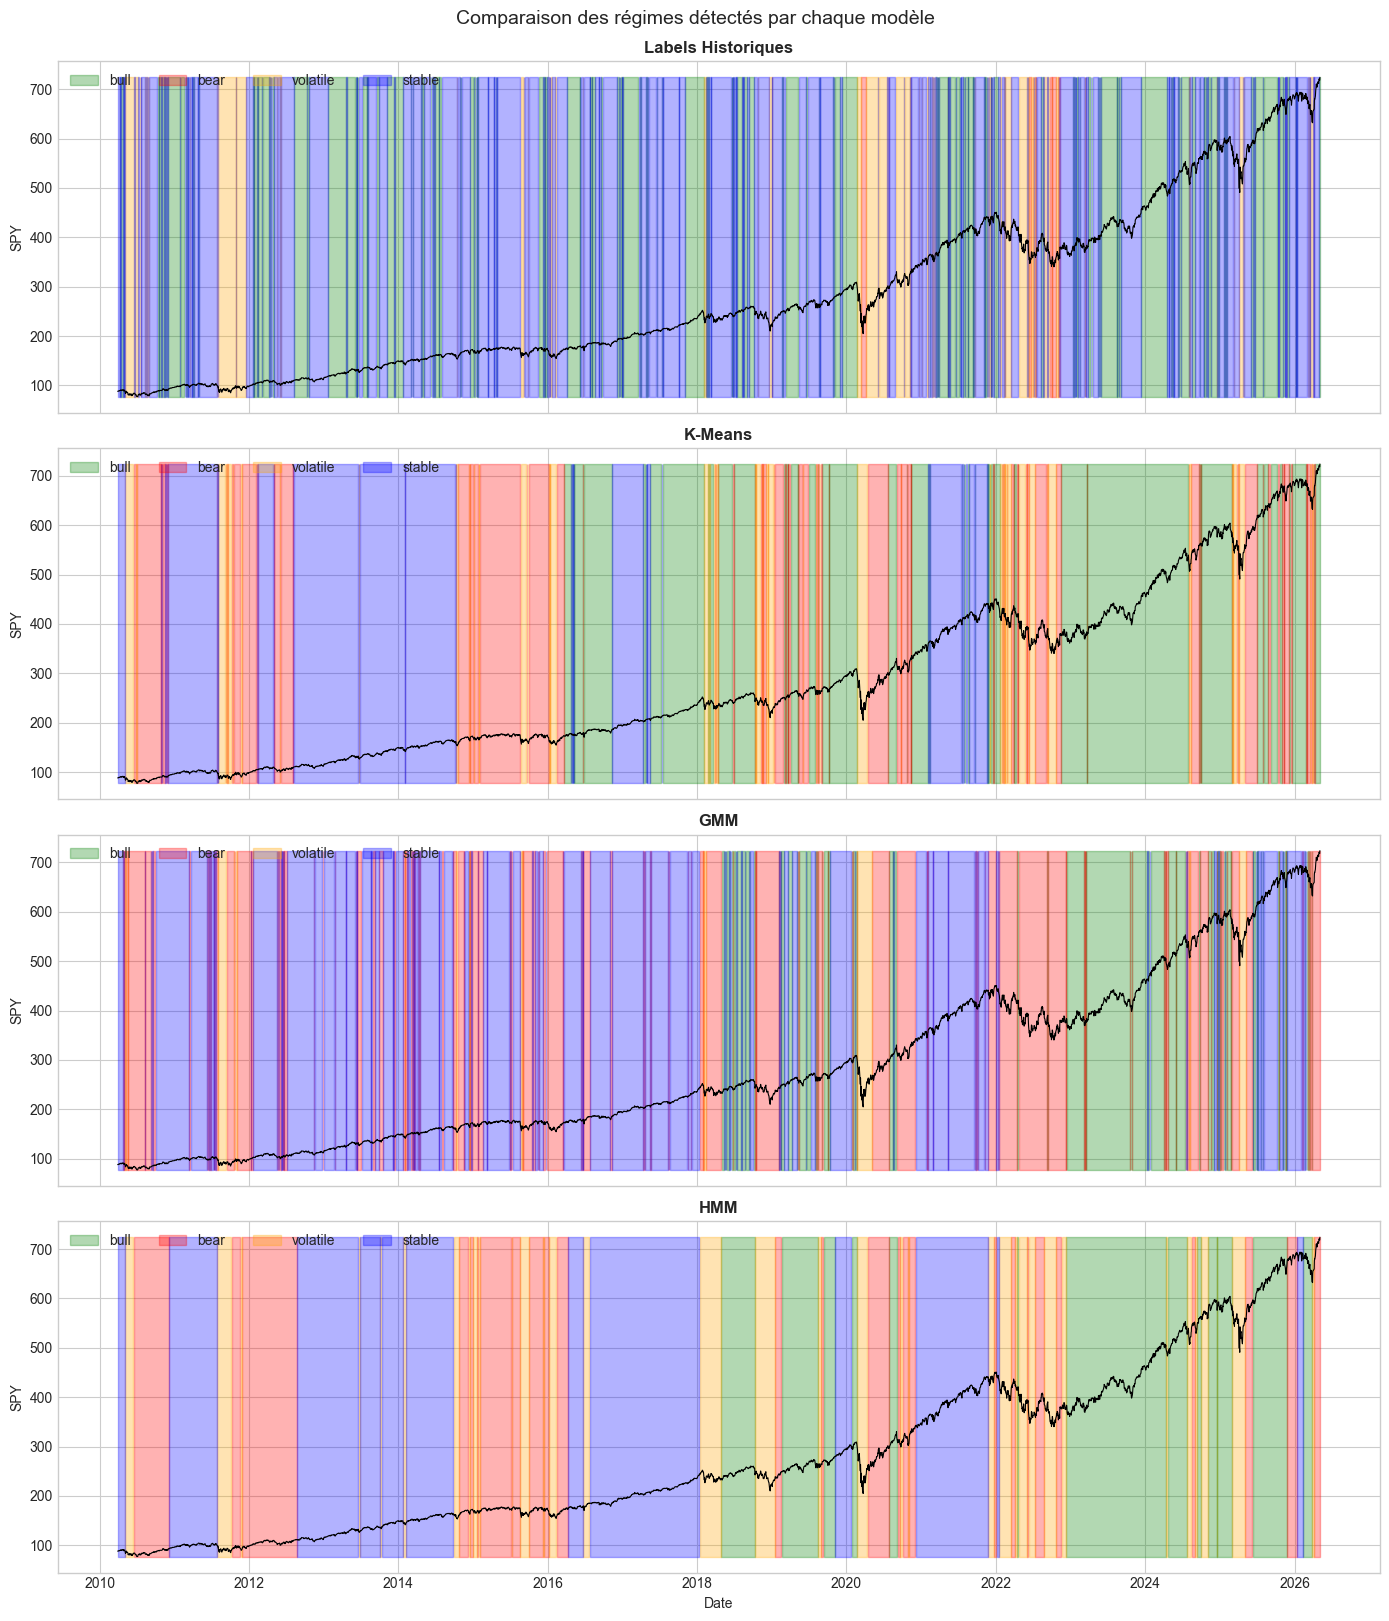

In [41]:
# Créer une figure avec 4 subplots
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

spy_prices = df_combined.loc[common_idx, 'SPY']
colors = {0: 'green', 1: 'red', 2: 'orange', 3: 'blue'}

all_labels = {
    'Labels Historiques': y_historical,
    'K-Means': labels_kmeans,
    'GMM': labels_gmm,
    'HMM': labels_hmm,
}

for ax, (title, labels) in zip(axes, all_labels.items()):
    ax.plot(spy_prices.index, spy_prices.values, color='black', linewidth=0.8)
    
    for regime, color in colors.items():
        mask = labels == regime
        if mask.any():
            ax.fill_between(
                spy_prices.index,
                spy_prices.min(),
                spy_prices.max(),
                where=mask,
                alpha=0.3,
                color=color,
                label=REGIME_NAMES[regime]
            )
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('SPY')
    ax.legend(loc='upper left', ncol=4)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.suptitle('Comparaison des régimes détectés par chaque modèle', y=1.01, fontsize=14)
plt.show()

## 7. Analyse HMM (modèle choisi)

In [42]:
# Matrice de transition HMM
trans_matrix = model_hmm.get_transition_matrix()

print("Matrice de transition HMM :")
print("(Probabilité de passer du régime ligne au régime colonne)")
print()
trans_matrix

Matrice de transition HMM :
(Probabilité de passer du régime ligne au régime colonne)



,bull,bear,volatile,stable
bull,0.986,0.002,0.011,0.001
bear,0.005,0.972,0.017,0.006
volatile,0.010,0.035,0.949,0.006
stable,0.001,0.000,0.007,0.991


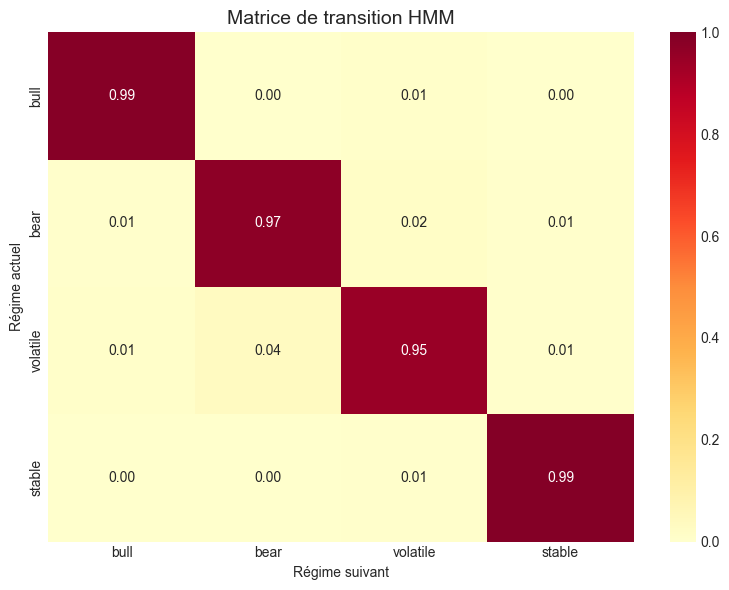

In [43]:
# Visualiser la matrice de transition
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    trans_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax,
    vmin=0,
    vmax=1,
)

ax.set_title('Matrice de transition HMM', fontsize=14)
ax.set_xlabel('Régime suivant')
ax.set_ylabel('Régime actuel')
plt.tight_layout()
plt.show()

In [44]:
# Distribution stationnaire
stationary = model_hmm.get_stationary_distribution()

print("Distribution stationnaire (long terme) :")
for regime, prob in stationary.items():
    print(f"  {regime}: {prob*100:.1f}%")

Distribution stationnaire (long terme) :
  bull: 0.0%
  bear: 0.0%
  volatile: 0.0%
  stable: 100.0%


In [45]:
# Statistiques par régime HMM
regime_stats = model_hmm.get_regime_stats(X_train)

print("Statistiques par régime HMM :")
regime_stats[['name', 'count', 'pct', 'avg_confidence', 'avg_duration_days']]

Statistiques par régime HMM :


,name,count,pct,avg_confidence,avg_duration_days
0,bull,965,23.8,0.992,74.2
1,bear,940,23.2,0.975,36.2
2,volatile,701,17.3,0.980,20.0
3,stable,1444,35.7,0.996,120.3


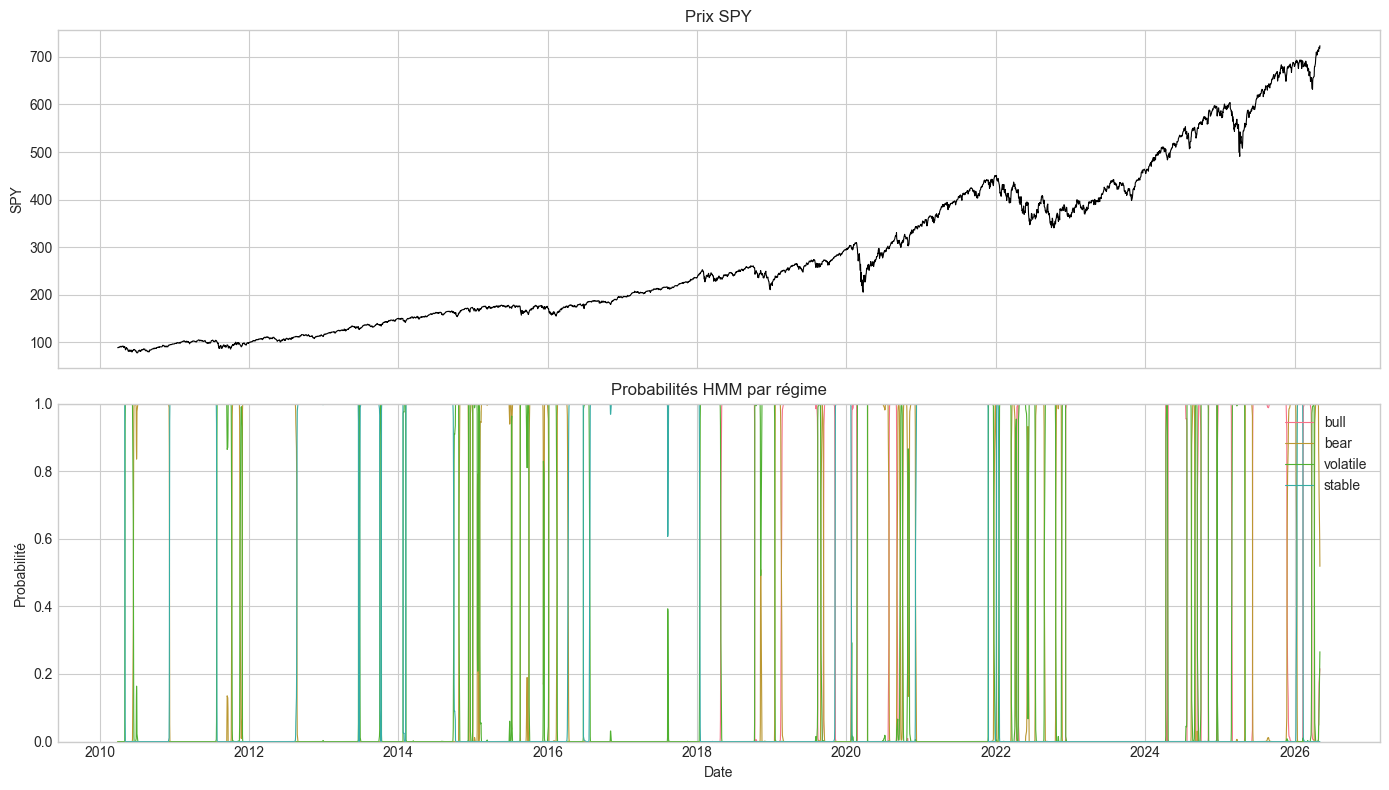

In [46]:
# Probabilités HMM au fil du temps
proba_df = model_hmm.predict_proba_df(X_train)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Prix SPY
axes[0].plot(spy_prices.index, spy_prices.values, color='black', linewidth=0.8)
axes[0].set_ylabel('SPY')
axes[0].set_title('Prix SPY', fontsize=12)

# Probabilités
for col in proba_df.columns:
    regime_name = col.replace('prob_', '')
    color = colors.get(list(REGIME_NAMES.values()).index(regime_name) if regime_name in REGIME_NAMES.values() else 0, 'gray')
    axes[1].plot(proba_df.index, proba_df[col], label=regime_name, linewidth=0.8)

axes[1].set_ylabel('Probabilité')
axes[1].set_xlabel('Date')
axes[1].set_title('Probabilités HMM par régime', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 8. Analyse des crises connues

In [47]:
# Vérifier les régimes pendant les crises connues
crisis_periods = get_crisis_periods()

print("Régimes détectés pendant les crises majeures :")
print("="*60)

for crisis_name, (start, end) in crisis_periods.items():
    mask = (labels_hmm.index >= start) & (labels_hmm.index <= end)
    if mask.any():
        crisis_regimes = labels_hmm[mask]
        dominant_regime = crisis_regimes.mode().iloc[0] if len(crisis_regimes) > 0 else -1
        dominant_name = REGIME_NAMES.get(dominant_regime, 'unknown')
        
        print(f"\n{crisis_name} ({start} à {end}):")
        print(f"  Régime dominant: {dominant_name}")
        for regime in range(N_REGIMES):
            pct = (crisis_regimes == regime).mean() * 100
            if pct > 0:
                print(f"    {REGIME_NAMES[regime]}: {pct:.1f}%")

Régimes détectés pendant les crises majeures :

Flash_Crash_2010 (2010-05-06 à 2010-05-06):
  Régime dominant: volatile
    volatile: 100.0%

Euro_Crisis_2011 (2011-07-01 à 2011-10-31):
  Régime dominant: volatile
    bear: 18.8%
    volatile: 61.2%
    stable: 20.0%

China_Fears_2015 (2015-08-01 à 2015-09-30):
  Régime dominant: volatile
    bear: 31.0%
    volatile: 69.0%

Vol_Spike_2018 (2018-02-01 à 2018-02-28):
  Régime dominant: volatile
    volatile: 100.0%

COVID_2020 (2020-02-20 à 2020-03-31):
  Régime dominant: volatile
    bull: 6.9%
    volatile: 93.1%

Rate_Hikes_2022 (2022-01-01 à 2022-10-31):
  Régime dominant: volatile
    bull: 2.9%
    bear: 28.2%
    volatile: 65.1%
    stable: 3.8%


## 9. Conclusion

In [48]:
# Tableau récapitulatif final
print("\n" + "="*70)
print("RÉSUMÉ DE LA COMPARAISON DES MODÈLES DE RÉGIME")
print("="*70)

print("\nMétriques clés :")
print(comparison_df.to_string())

print("\n" + "-"*70)
print("CONCLUSION")
print("-"*70)

# Déterminer le meilleur modèle
best_silhouette = comparison_df['silhouette'].idxmax()
best_stability = comparison_df['stability'].idxmax()
best_ari = comparison_df['adj_rand_index'].idxmax() if 'adj_rand_index' in comparison_df.columns else 'N/A'

print(f"\n1. Meilleur Silhouette Score: {best_silhouette}")
print(f"2. Meilleure stabilité: {best_stability}")
print(f"3. Meilleur ARI vs historique: {best_ari}")

print("\n" + "-"*70)
print("""CHOIX FINAL: HMM (Hidden Markov Model)

Justification:
- Le HMM capture la dynamique TEMPORELLE des régimes (transitions)
- Produit des régimes plus STABLES (moins de changements intempestifs)
- La matrice de transition permet d'interpréter les probabilités de changement
- Fournit des probabilités par régime (utile pour ajuster les poids)
- Meilleure adéquation avec la réalité des marchés (régimes persistants)

Limitations:
- Plus lent à entraîner que K-Means
- Sensible à l'initialisation (résolu avec random_state fixe)
- Suppose des distributions gaussiennes pour les émissions
""")
print("-"*70)


RÉSUMÉ DE LA COMPARAISON DES MODÈLES DE RÉGIME

Métriques clés :
         silhouette  calinski_harabasz  stability  regime_changes  adj_rand_index  accuracy_vs_hist
model                                                                                              
K-Means      0.2149            1308.54     0.9407             240          0.0970            0.3523
GMM          0.1468             808.93     0.9106             362          0.1113            0.3412
HMM          0.1991            1009.02     0.9790              85          0.0697            0.3679

----------------------------------------------------------------------
CONCLUSION
----------------------------------------------------------------------

1. Meilleur Silhouette Score: K-Means
2. Meilleure stabilité: HMM
3. Meilleur ARI vs historique: GMM

----------------------------------------------------------------------
CHOIX FINAL: HMM (Hidden Markov Model)

Justification:
- Le HMM capture la dynamique TEMPORELLE des régime

In [49]:
# Sauvegarder les résultats
comparison_df.to_csv('../data/processed/regime_model_comparison.csv')
print("Résultats sauvegardés dans data/processed/regime_model_comparison.csv")

Résultats sauvegardés dans data/processed/regime_model_comparison.csv
